In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv(r"C:\Users\louis\OneDrive - ECAM\ECAM\IA\labo\student_dataset\student_failure\train.csv")



print(df.shape)     # nombre de lignes / colonnes
print(df.columns)   # noms des colonnes
df.head()


(630000, 15)
Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='object')


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


# nettoyage des données


In [2]:
def categorize(score):
    if score < 50:
        return "fail"
    elif score <= 60:
        return "risk"
    else:
        return "pass"

df["target"] = df["score_examen"].apply(categorize)
df["target"].value_counts()

target
pass    358085
fail    161083
risk    110832
Name: count, dtype: int64

# EDA

In [3]:
ids = df["id"]

df = df.drop(columns=["id"])
X = df.drop(columns=["score_examen", "target"])
y = df["target"]

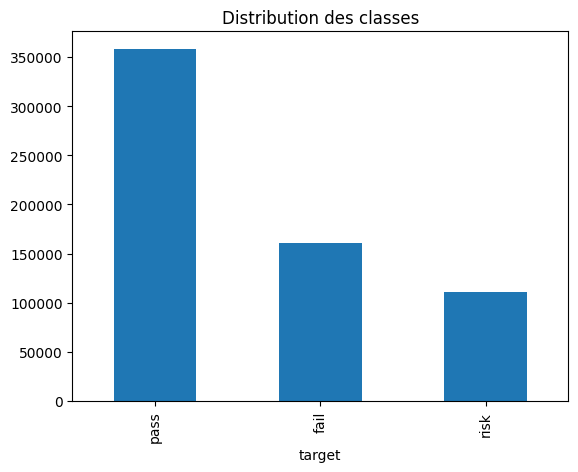

In [4]:
#distribution des classes
df["target"].value_counts().plot(kind="bar")
plt.title("Distribution des classes")
plt.show()

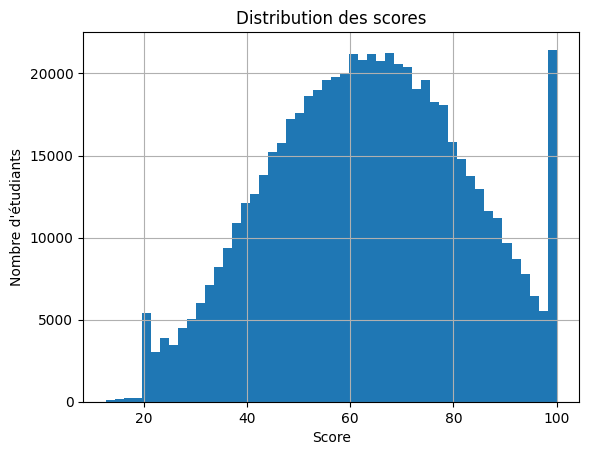

In [5]:
#distribution des notes

df["score_examen"].hist(bins=50)
plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Nombre d'étudiants")
plt.show()

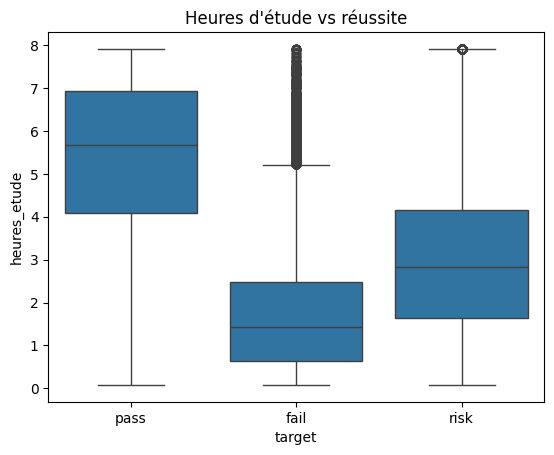

In [6]:
import seaborn as sns

sns.boxplot(x="target", y="heures_etude", data=df)
plt.title("Heures d'étude vs réussite")
plt.show()

on peut voir que le nombre etude est fortement correllé a la reussite scolaire. Cependant on peut aussi observer que certains eleves ont très peu etudié voir pas et on quand meme reussi. Le nombre heure etude suel ne suffit pas a explqiuer la reussite

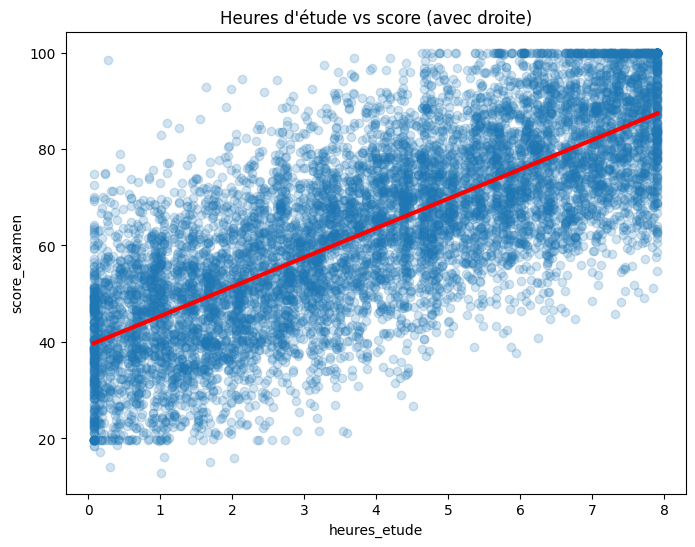

0.757647708785116


In [7]:

sample = df.sample(10000)

plt.figure(figsize=(8,6))

sns.regplot(
    x="heures_etude",
    y="score_examen",
    data=sample,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red", "linewidth": 3}
)

plt.title("Heures d'étude vs score (avec droite)")
plt.show()

print(df["heures_etude"].corr(df["score_examen"]))

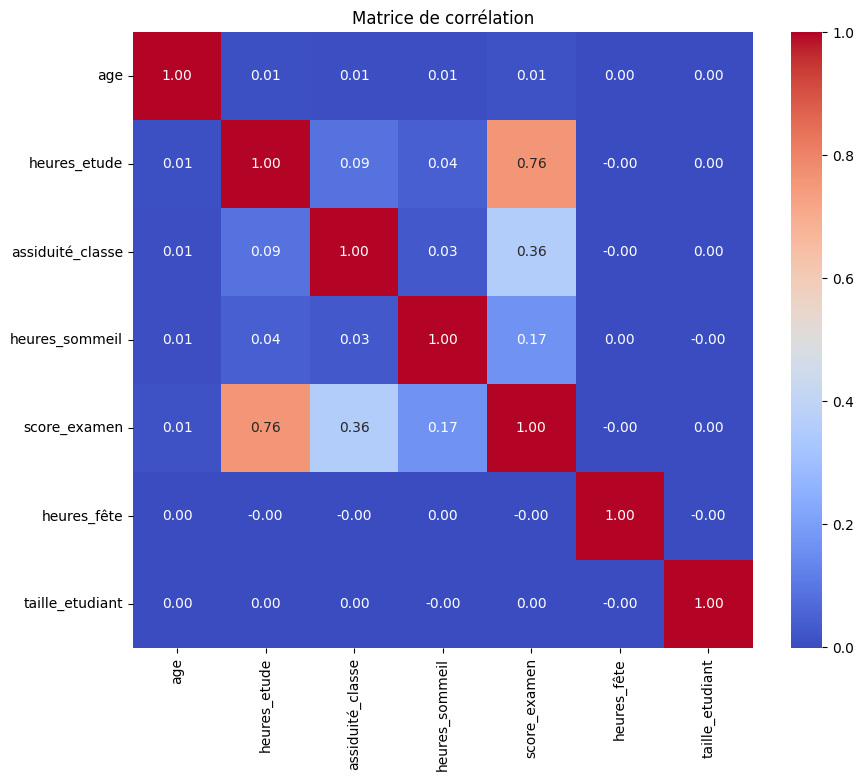

In [8]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


Types après encoding :
age                                  int64
genre                                int64
heures_etude                       float64
assiduité_classe                   float64
accès_internet                     float64
heures_sommeil                     float64
qualité_sommeil                      int64
évaluation_établissement             int64
difficulté_examen                    int64
score_examen                       float64
heures_fête                          int64
taille_etudiant                    float64
diplôme_Business Administration       bool
diplôme_Business Management           bool
diplôme_Computer Science              bool
diplôme_Engineering                   bool
diplôme_Law                           bool
diplôme_Marketing                     bool
méthode_etude_group study             bool
méthode_etude_mixed                   bool
méthode_etude_online videos           bool
méthode_etude_self-study              bool
méthode_etude_unknown         

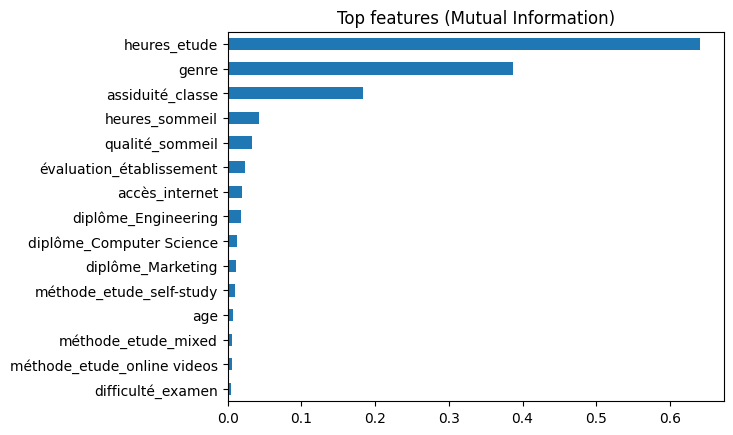

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. LOAD
# -------------------------
df = pd.read_csv(r"C:\Users\louis\OneDrive - ECAM\ECAM\IA\labo\student_dataset\student_failure\train.csv")

# -------------------------
# 2. COPIE
# -------------------------
df_ml = df.copy()

# -------------------------
# 3. SUPPRIMER ID
# -------------------------
df_ml = df_ml.drop(columns=["id"])

# -------------------------
# 4. GESTION DES NaN (propre)
# -------------------------

# numérique → moyenne
num_cols = df_ml.select_dtypes(include=np.number).columns
df_ml[num_cols] = df_ml[num_cols].fillna(df_ml[num_cols].mean())

# catégoriel → "unknown"
cat_cols = df_ml.select_dtypes(include="object").columns
df_ml[cat_cols] = df_ml[cat_cols].fillna("unknown")

# -------------------------
# 5. ENCODING
# -------------------------

# ---- binaire
df_ml["genre"] = df_ml["genre"].map({"male": 0, "female": 1}).fillna(0)
df_ml["accès_internet"] = df_ml["accès_internet"].map({"yes": 1, "no": 0}).fillna(0)

# ---- ordinal
df_ml["qualité_sommeil"] = df_ml["qualité_sommeil"].map({
    "poor": 0,
    "average": 1,
    "good": 2,
    "excellent": 3
}).fillna(1)

df_ml["évaluation_établissement"] = df_ml["évaluation_établissement"].map({
    "low": 0,
    "medium": 1,
    "high": 2
}).fillna(1)

df_ml["difficulté_examen"] = df_ml["difficulté_examen"].map({
    "easy": 0,
    "moderate": 1,
    "hard": 2
}).fillna(1)

# ---- nominal → one-hot
df_ml = pd.get_dummies(
    df_ml,
    columns=["diplôme", "méthode_etude"],
    drop_first=True
)

# -------------------------
# 6. CHECK FINAL
# -------------------------

print("\nTypes après encoding :")
print(df_ml.dtypes)

print("\nNombre de NaN restants :")
print(df_ml.isna().sum().sum())

assert df_ml.isna().sum().sum() == 0, "Il reste des NaN !"

assert not any(df_ml.dtypes == "object"), "Il reste des variables non numériques !"

# -------------------------
# 7. MUTUAL INFORMATION
# -------------------------

from sklearn.feature_selection import mutual_info_regression

X = df_ml.drop(columns=["score_examen"])
y = df_ml["score_examen"]

mi = mutual_info_regression(X, y)

mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print("\nTop variables importantes :")
print(mi.head(20))

# -------------------------
# 8. VISUALISATION
# -------------------------

mi.head(15).sort_values().plot(kind="barh")
plt.title("Top features (Mutual Information)")
plt.show()

In [10]:
from sklearn.feature_selection import mutual_info_regression

X = df_ml.drop(columns=["score_examen"])
y = df_ml["score_examen"]

mi = mutual_info_regression(X, y)

mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi.head(15))

heures_etude                   0.641277
genre                          0.384154
assiduité_classe               0.181998
heures_sommeil                 0.042558
qualité_sommeil                0.034782
évaluation_établissement       0.023893
accès_internet                 0.020709
diplôme_Engineering            0.017971
diplôme_Computer Science       0.013485
diplôme_Marketing              0.010486
méthode_etude_self-study       0.009027
age                            0.007578
méthode_etude_online videos    0.004236
méthode_etude_mixed            0.004083
méthode_etude_group study      0.003680
dtype: float64


In [11]:
from sklearn.feature_selection import mutual_info_regression

mi_sleep = mutual_info_regression(
    df_ml[["heures_sommeil"]],
    df_ml["qualité_sommeil"]
)

print(mi_sleep)

#df_ml["sleep_interaction"] = df_ml["heures_sommeil"] * df_ml["qualité_sommeil"]
#mi = mutual_info_regression(X, y)
#print(mi)

[0.00242236]
[6.94593139e-03 3.84083271e-01 6.41209470e-01 1.82899162e-01
 2.15794736e-02 4.32132018e-02 3.34834653e-02 2.55803102e-02
 4.21624311e-03 0.00000000e+00 1.52215447e-04 0.00000000e+00
 4.03752051e-03 1.29722371e-02 2.07211028e-02 2.33495891e-03
 1.08140330e-02 3.19961392e-03 4.90054145e-03 4.26064805e-03
 1.02161214e-02 0.00000000e+00]


# heatmap utile 

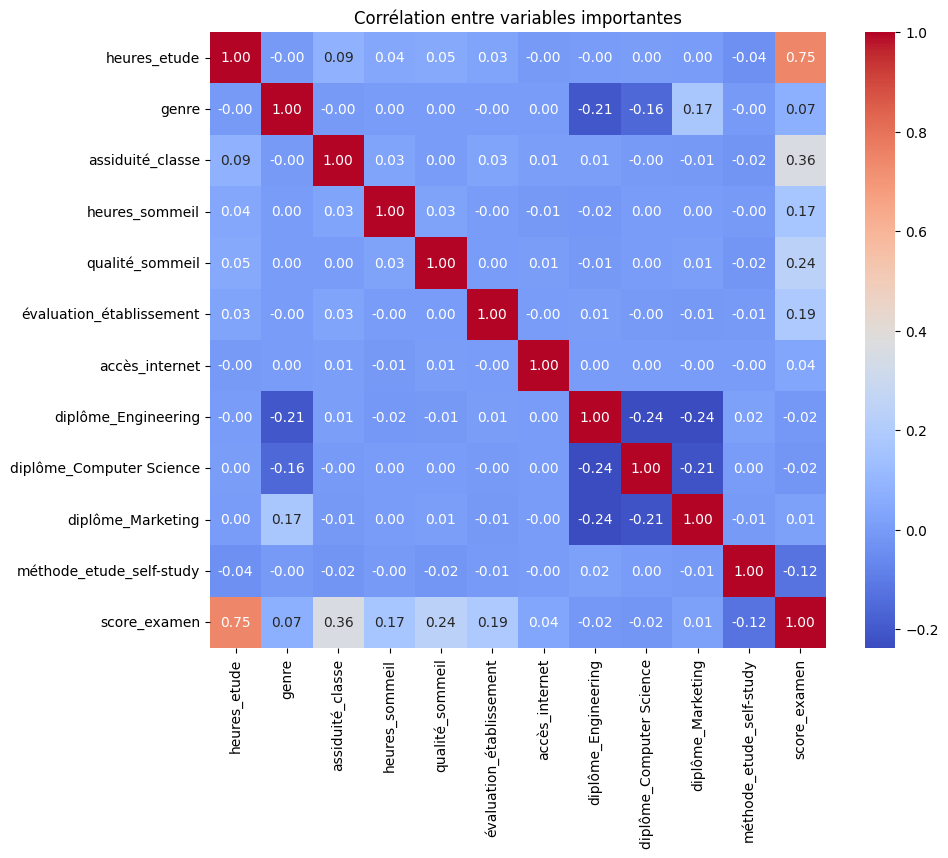

In [13]:
mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

important_features = mi[mi > 0.01].index.tolist()

# ajouter la target
important_features.append("score_examen")

corr = df_ml[important_features].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Corrélation entre variables importantes")
plt.show()